In [32]:
import pandas as pd
import numpy as np
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

# 1. Data Preprocessing (Review & Extension)

In [33]:
df = pd.read_csv('data/marketing_campaign.csv', sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [34]:
df.shape

(2240, 29)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [36]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [37]:
df['Income']=df['Income'].fillna(df['Income'].median())

In [38]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [39]:
df.duplicated().sum()

np.int64(0)

## Feature Engineering

In [40]:
current_year = 2026  
df['Age'] = current_year - df['Year_Birth']

# عبر جمع أعمدة المنتجات المختلفة (TotalSpending) حساب إجمالي الإنفاق
spending_columns = [
    'MntWines', 'MntFruits', 'MntMeatProducts', 
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]
df['TotalSpending'] = df[spending_columns].sum(axis=1)

# من خلال جمع الأطفال والمراهقين في المنزل (TotalChildren) حساب إجمالي عدد الأطفال
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']

# معاينة الأعمدة الجديدة للتأكد من صحة الحسابات
df[['Year_Birth', 'Age', 'TotalSpending', 'TotalChildren']].head()

,Year_Birth,Age,TotalSpending,TotalChildren
0,1957,69,1617,0
1,1954,72,27,2
2,1965,61,776,0
3,1984,42,53,1
4,1981,45,422,1


## Filtering

In [41]:
# الإبقاء فقط على الأعمار الواقعية (من 18 إلى 100 سنة)
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]

# إزالة الصفوف التي يكون فيها الدخل صفر أو أقل (الإبقاء على الدخل الأكبر من صفر)
df = df[df['Income'] > 0]

# معاينة أبعاد البيانات (عدد الصفوف والأعمدة) بعد التصفية للتأكد من حذف الصفوف المستهدفة
print(f"Data shape after filtering: {df.shape}")

Data shape after filtering: (2237, 32)


## Encoding

In [42]:
# (Education) الترميز الترتيبي لعمود التعليم
education_mapping = {
    'Basic': 0,
    'Graduation': 1,
    '2n Cycle': 2,
    'Master': 2,
    'PhD': 3
}
df['Education'] = df['Education'].map(education_mapping)

# One-Hot Encoding  قبل ال (Marital_Status) تجهيز عمود الحالة الاجتماعية
# تحديد أعلى 4 فئات تكراراً في البيانات
top_4_marital = df['Marital_Status'].value_counts().index[:4]

# 'Other' دمج الفئات الأخرى المتبقية تحت اسم 
df['Marital_Status'] = df['Marital_Status'].apply(lambda x: x if x in top_4_marital else 'Other')

# Marital_Status على عمود One-Hot Encoding تطبيق ال
# سيتم إنشاء أعمدة جديدة لكل فئة وحذف العمود الأصلي تلقائياً
df = pd.get_dummies(df, columns=['Marital_Status'], prefix='Marital', drop_first=False)

# معاينة شكل البيانات والأعمدة الجديدة للتأكد من نجاح الخطوة
df.head()

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Z_Revenue,Response,Age,TotalSpending,TotalChildren,Marital_Divorced,Marital_Married,Marital_Other,Marital_Single,Marital_Together
0,5524,1957,1,58138.0,0,0,04-09-2012,58,635,88,...,11,1,69,1617,0,False,False,False,True,False
1,2174,1954,1,46344.0,1,1,08-03-2014,38,11,1,...,11,0,72,27,2,False,False,False,True,False
2,4141,1965,1,71613.0,0,0,21-08-2013,26,426,49,...,11,0,61,776,0,False,False,False,False,True
3,6182,1984,1,26646.0,1,0,10-02-2014,26,11,4,...,11,0,42,53,1,False,False,False,False,True
4,5324,1981,3,58293.0,1,0,19-01-2014,94,173,43,...,11,0,45,422,1,False,True,False,False,False


# 2. Supervised Learning - Regression 

In [43]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# (Features) عن الميزات (Target) فصل المتغير المستهدف
X = df.drop(columns=['TotalSpending','Dt_Customer'])
y = df['TotalSpending']

# تقسيم البيانات إلى مجموعتي التدريب والاختبار (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# على الميزات الرقمية (StandardScaler) تطبيق قياس الميزات
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. تعريف النماذج الثلاثة المطلوبة
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression (alpha=1.0)": Ridge(alpha=1.0),
    "Decision Tree Regressor (max_depth=5)": DecisionTreeRegressor(max_depth=5, random_state=42)
}

# تدريب النماذج وحساب مقاييس الأداء
results = []

for name, model in models.items():
    # تدريب النموذج
    model.fit(X_train_scaled, y_train)
    
    # التنبؤ على بيانات الاختبار
    y_pred = model.predict(X_test_scaled)
    
    # حساب المقاييس
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # حفظ النتائج
    results.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "R² Score": r2
    })

# 6. إنشاء جدول المقارنة وعرضه
comparison_df = pd.DataFrame(results)
print("\n--- جدول مقارنة أداء نماذج الانحدار ---")
print(comparison_df.to_string(index=False))


--- جدول مقارنة أداء نماذج الانحدار ---
                                Model          MSE         RMSE  R² Score
                    Linear Regression 6.828813e-25 8.263663e-13  1.000000
         Ridge Regression (alpha=1.0) 1.661572e-01 4.076238e-01  1.000000
Decision Tree Regressor (max_depth=5) 1.626342e+04 1.275281e+02  0.957187


# Why Ridge Regression?
We implemented Ridge Regression with alpha=1.0 to apply L2 regularization. This adds a penalty to the loss function based on the magnitude of the coefficients, helping to prevent overfitting and handle potential multicollinearity between features.

Why Decision Tree with max_depth=5?
Limiting the tree depth to 5 helps control the model complexity. A fully grown tree can easily overfit the training data, while restricting the depth ensures the model generalizes better to unseen test data.

# 3. Supervised Learning - Classification 

Class Distribution:
Response
0    1903
1     334
Name: count, dtype: int64

=================== Logistic Regression Report ===================
              precision    recall  f1-score   support

           0       0.95      0.81      0.88       381
           1       0.42      0.78      0.54        67

    accuracy                           0.81       448
   macro avg       0.69      0.79      0.71       448
weighted avg       0.87      0.81      0.83       448



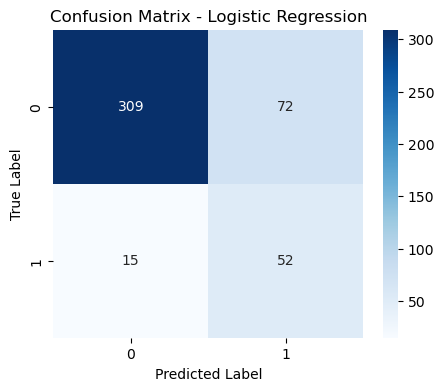


=================== K-Nearest Neighbors Report ===================
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       381
           1       0.68      0.31      0.43        67

    accuracy                           0.88       448
   macro avg       0.78      0.64      0.68       448
weighted avg       0.86      0.88      0.85       448



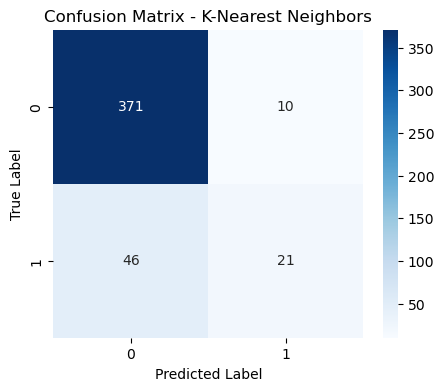


=================== Random Forest Report ===================
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       381
           1       0.69      0.33      0.44        67

    accuracy                           0.88       448
   macro avg       0.79      0.65      0.69       448
weighted avg       0.86      0.88      0.86       448



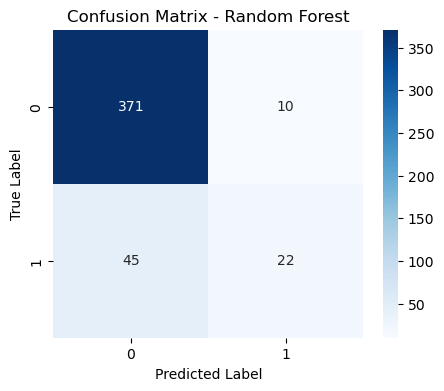

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# طباعة توزيع الفئات وفحص عدم التوازن
print("Class Distribution:")
print(df['Response'].value_counts())

# فصل الميزات والهدف وتقسيم البيانات (مع استبعاد عمود التاريخ النصي والهدف)
X = df.drop(columns=['Response', 'Dt_Customer'])
y = df['Response']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# للموديلات الخطية والمعتمدة على المسافة (StandardScaler) التقييس
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# بناء وتدريب النماذج الثلاثة 
lr = LogisticRegression(class_weight='balanced', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# تدريب الموديلات
lr.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)

# التنبؤ واستخراج التقارير ومصفوفة الارتباك لكل نموذج
models_list = [('Logistic Regression', lr, X_test_scaled), 
               ('K-Nearest Neighbors', knn, X_test_scaled), 
               ('Random Forest', rf, X_test)]

for name, model, X_data in models_list:
    preds = model.predict(X_data)
    
    print(f"\n=================== {name} Report ===================")
    print(classification_report(y_test, preds))
    
    # حساب مصفوفة الارتباك
    cm = confusion_matrix(y_test, preds)
    
    # رسم مصفوفة الارتباك
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

## Handling Class Imbalance:
The target variable Response is highly imbalanced (the majority of customers did not respond). To handle this, we used class_weight='balanced' in Logistic Regression, which adjusts the weights inversely proportional to class frequencies. We also used the stratify=y parameter during the train/test split to maintain the exact class distribution in both sets.

## Which Metric is Most Important Here and Why?
In this marketing campaign context, Recall for Class 1 (or the F1-Score) is the most important metric. If the cost of sending a marketing offer is low (e.g., emails), the company wants to capture as many potential buyers as possible (minimize False Negatives). Missing a customer who would have responded means losing real revenue. Therefore, Accuracy is misleading here, and we focus on maximizing the model's ability to detect the rare positive class.

# 4. Unsupervised Learning - Clustering 

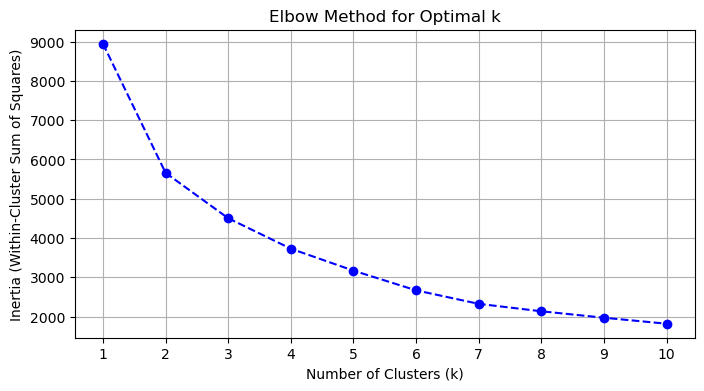

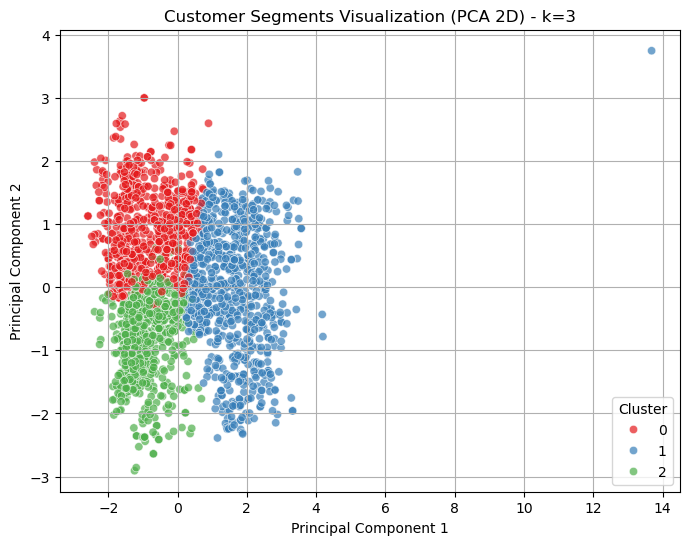


--- (Cluster Profiling) المتوسطات الحسابية لكل مجموعة  ---
         TotalSpending        Income        Age  TotalChildren
Cluster                                                       
0           298.545070  47278.929577  63.940845       1.690141
1          1289.276382  74150.170854  58.640704       0.391960
2           159.804378  33161.607387  48.772914       0.841313


In [45]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# اختيار الميزات الأربعة المطلوبة وتقييسها

features = ['TotalSpending', 'Income', 'Age', 'TotalChildren']
X_clustering = df[features]

#( لأن المسافات تتأثر بالأحجام PCA وال K-Means تقييس البيانات (ضروري جداً قبل ال
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# (K) تحديد عدد المجموعات الأنسب

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# رسم الخطأ 
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.show()


#k=3 بالقيمة K-Means تدريب نموذج

# k=3 ملاحظة: عادةً في هذه البيانات يظهر الانكسار الواضح عند
optimal_k = 3 
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_scaled)

# إلى إطار البيانات الأصلي (Labels) إضافة التسميات
df['Cluster'] = cluster_labels


# (2D) لغرض الرسم ثنائي الأبعاد PCA  تقليل الأبعاد باستخدام

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# إنشاء جدول مؤقت للرسم
pca_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = cluster_labels

# (Scatter Plot) رسم المجموعات
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='Set1', data=pca_df, alpha=0.7)
plt.title(f'Customer Segments Visualization (PCA 2D) - k={optimal_k}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


#(Cluster Profiling) تحليل خصائص المجموعات 

print("\n--- (Cluster Profiling) المتوسطات الحسابية لكل مجموعة  ---")
profile = df.groupby('Cluster')[features].mean()
print(profile)

## Why k=3  for Clusters?
Based on the Elbow Method plot, the optimal number of clusters is determined by finding the "elbow point" where the inertia (Within-Cluster Sum of Squares) stops decreasing sharply. In this dataset, the sharp bend occurs at $k=3$, indicating that adding more clusters will not significantly improve the segmentation.The Role of PCA in Clustering:We train the K-Means model on the 4 original scaled features to preserve the geometric distances. PCA is used strictly after clustering to project the high-dimensional data into 2 principal components (2D) for visualization purposes only.